# Ising Model Example Solution

In [2]:
from ising_functions import *

## Simulation

### Running the Simulation

In [165]:
n_sweeps = 100000
L = 3
T = [1.5, 2.27, 3.00]
K = 1
h = 0
snapshots = snapshot_series(n_sweeps, L, T[0], K, h)

In [ ]:
final_snapshots = ensemble_simulation(3000, 500, L, T[0], K, h)

In [5]:
from itertools import product

In [166]:
def generate_microstates(L):
    for state in product([-1,1], repeat=3*3):
        yield np.asarray(state).reshape((3,3))

In [167]:
microstates = generate_microstates(3)
boltzmann_weights = np.zeros(2**9)
params = {"temperature" : 1.5, "interaction_strength" : 1, "external_field" : 0}
for state in microstates:
    n = state_to_int(state)
    E = tot_H(state, params)
    boltzmann_weights[n] = np.exp(-E/params["temperature"])
# normalize
boltzmann_weights /= boltzmann_weights.sum()

In [168]:
def state_to_int(lattice):
    # convert to 1s and 0s
    lattice = (lattice + 1)//2
    lattice = lattice.flatten()
    # convert to binary
    bin_str = ''.join(lattice.astype(str))
    return int(bin_str, 2)

In [169]:
montecarlo_microstates = [state_to_int(snap) for snap in snapshots]

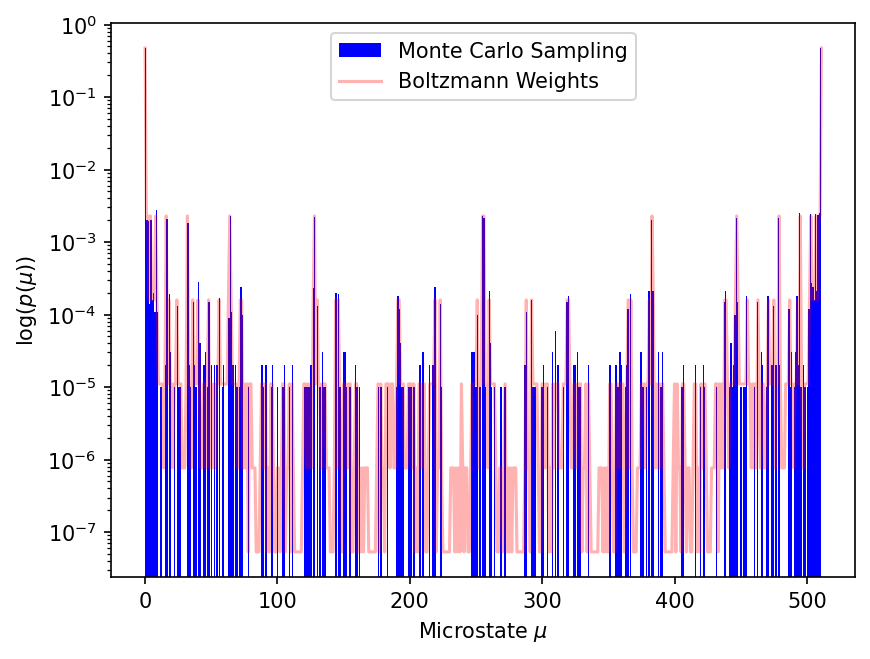

In [170]:
fig, ax = plt.subplots(dpi=150)
ax.hist(montecarlo_microstates, bins=512, density=True, color="blue", label="Monte Carlo Sampling")
ax.plot(boltzmann_weights, color="red", alpha=0.3, label="Boltzmann Weights")
ax.set_yscale("log")
ax.set_ylabel(r"$\log(p(\mu))$")
ax.set_xlabel(r"Microstate $\mu$")
ax.legend()

### Animation

In [3]:
from matplotlib import animation, rcParams
from IPython.display import HTML
from imageio_ffmpeg import get_ffmpeg_exe
rcParams['animation.ffmpeg_path'] = get_ffmpeg_exe()

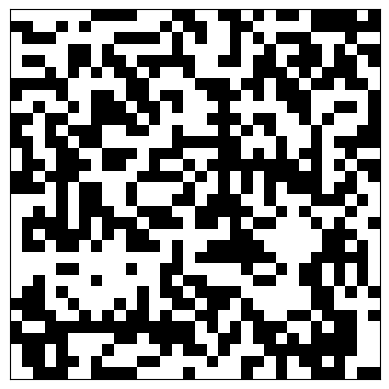

In [4]:
fig, ax = plt.subplots()
anim_frames = snapshots[::2]
im = ax.imshow(anim_frames[0], cmap="gray")
ax.set_xticks([])
ax.set_yticks([])

def update_frame(n):
    im.set_array(anim_frames[n])
    return im,

In [5]:
anim = animation.FuncAnimation(fig, func=update_frame, frames=len(anim_frames), interval=50, blit=True)
HTML(anim.to_jshtml())

## Measurements

In [195]:
def magnetization_series(snapshots):
    N = snapshots[0].size
    m = np.sum(snapshots, axis=(1,2))/N
    return m

In [ ]:
N = snapshots[0].size
m = np.sum(snapshots, axis=(1,2))/N
m2 = np.sum(snapshots**2, axis = (1,2))/2
chi = (m2 - m**2)/(T[2]*N**2)

In [233]:
lowT_ms = np.mean(final_snapshots, axis=(1,2))
thermalized_lowT_ms = lowT_ms[np.abs(lowT_ms) > 0.8]

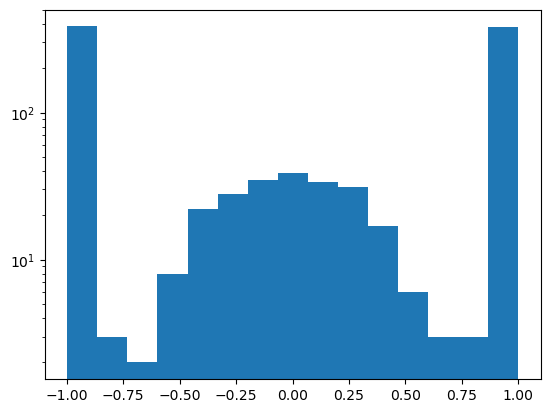

In [ ]:
fig, ax = plt.subplots()
ax.hist(lowT_ms, bins=15)
ax.set_yscale("log")
ax.set_title(f"Ising Model Free Energy (t = {1.5/2.27})")
ax.set_xlabel("m")
ax.set_ylabel("log(P)")

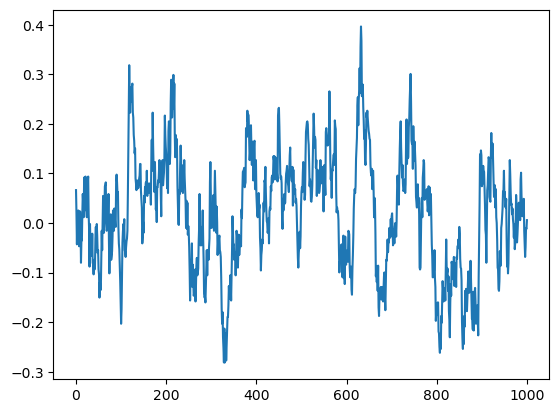

In [174]:
plt.plot(m)